In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_excel('nigeria_messy_sales_dataset.xlsx')
df

,Customer Name,State,Product,Units Sold,Unit Price,Total Sale,Sale Date,Sales Channel,Order ID
0,NaN,rivers,KEYBOARD,NaN,NaN,NaN,2025-04-27,Online,NaN
1,Allison Hill,Lagos,Headphones,NaN,267992.94,NaN,2024-03-15,Wholesale,4c636e95-025f-4543-8997-623ae0723d96
2,Noah Rhodes,Anambra,Keyboard,NaN,42364.41,NaN,2024-12-10,NaN,edaf3766-1b78-4ede-9a4f-fc0c9165f2ed
3,Angie Henderson,Delta,Keyboard,NaN,279444.94,NaN,2024-04-05,NaN,74503887-48d9-4846-95c5-51fcfba57cc8
4,Daniel Wagner,Delta,Tablet,NaN,95899.74,NaN,2025-01-12,NaN,8639bd41-8b15-4d94-a42d-0cd7fd359f6a
...,...,...,...,...,...,...,...,...,...
545,Zachary Mitchell,Ekiti,Monitor,6.0,23989.09,143934.54,2025-07-07,Wholesale,b9744cde-d259-4960-aee3-560792ea1324
546,NaN,Katsina,Tablet,NaN,223764.24,NaN,2025-02-11,Wholesale,NaN
547,Katherine Martinez,Bauchi,Phone,NaN,104084.92,NaN,2025-05-18,Retail,61fa8e7a-078c-46ce-bf02-23bc651ea252
548,Jodi Roach,Niger,Charger,NaN,29756.89,NaN,2025-06-29,Direct,5a9c0679-2c3d-47e2-ad39-da75aee70ab2


In [4]:
df.shape

(550, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Customer Name  507 non-null    object        
 1   State          550 non-null    object        
 2   Product        550 non-null    object        
 3   Units Sold     155 non-null    float64       
 4   Unit Price     495 non-null    float64       
 5   Total Sale     137 non-null    float64       
 6   Sale Date      550 non-null    datetime64[ns]
 7   Sales Channel  444 non-null    object        
 8   Order ID       510 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 38.8+ KB


In [6]:
df.describe()

,Units Sold,Unit Price,Total Sale,Sale Date
count,155.000000,495.000000,1.370000e+02,550
mean,46.858065,155703.699212,7.075166e+06,2024-07-18 10:25:44.727272704
min,1.000000,1403.130000,5.788704e+04,2023-07-15 00:00:00
25%,24.500000,84873.975000,1.788402e+06,2024-02-06 00:00:00
50%,47.000000,157889.240000,5.049848e+06,2024-07-28 12:00:00
75%,67.500000,224577.170000,1.119981e+07,2025-01-07 06:00:00
max,100.000000,299437.800000,2.873459e+07,2025-07-10 00:00:00
std,26.973156,84443.013217,6.338224e+06,NaN


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
#missing values
df.isnull().sum()


Customer Name     43
State              0
Product            0
Units Sold       395
Unit Price        55
Total Sale       413
Sale Date          0
Sales Channel    106
Order ID          40
dtype: int64

#  Data Cleaning

In [9]:
#Filling the missing values with mode since it is a categorical variable
df['Customer Name']= df['Customer Name'].fillna(df['Customer Name'].mode()[0])

#Filling the missing values with the mean or median of the Units Sold because they have a small difference
df['Units Sold'] = df["Units Sold"].fillna(df['Units Sold'].median())

#Here i first got the difference between the median and mean which was big 
median = df['Unit Price'].median() 
mean = df['Unit Price'].mean()
diff = median - mean
print("diff:", diff)

#So here i used median because it was greater than the mean
df['Unit Price']= df['Unit Price'].fillna(df["Unit Price"].median())

#Here i got the Total Sale by multiplying the unit_sold with the unit_price
unit_sold = df['Units Sold']
unit_price = df["Unit Price"]
df['Total Sale'] = unit_sold * unit_price
df[['Units Sold', 'Unit Price', 'Total Sale']]

diff: 2185.5407878787664


,Units Sold,Unit Price,Total Sale
0,47.0,157889.24,7420794.28
1,47.0,267992.94,12595668.18
2,47.0,42364.41,1991127.27
3,47.0,279444.94,13133912.18
4,47.0,95899.74,4507287.78
...,...,...,...
545,6.0,23989.09,143934.54
546,47.0,223764.24,10516919.28
547,47.0,104084.92,4891991.24
548,47.0,29756.89,1398573.83


In [10]:
#Checking whether the missing values were reducing
df.isnull().sum()

#I filled missing values of the Sales Channel with the mode (Direct) 
df['Sales Channel'] = df['Sales Channel'].fillna(df['Sales Channel'].mode()[0])

In [11]:
df['Product'].value_counts()

Product
Tablet        73
Keyboard      72
Monitor       64
Laptop        61
Camera        57
Charger       56
Phone         50
Headphones    48
KEYBOARD      17
TABLET        12
HEADPHONES     9
CAMERA         8
PHONE          7
MONITOR        7
LAPTOP         6
CHARGER        3
Name: count, dtype: int64

In [12]:
product_mapping = {'Keyboard':'Keyboard', 'KEYBOARD':'Keyboard', 'Monitor': 'Mornitor',
    'MONITOR':'Mornitor', 'Headphones':'Headphones', 'HEADPHONES':'Headphones', 'Tablet':'Tablet', 
    'TABLET':'Tablet', 'Laptop':'Laptop', 'LAPTOP': 'Laptop', 'Camera':'Camera', 
    'CAMERA':'Camera', 'Charger':'Charger', 'CHARGER':'Charger', 'Phone': "Phone", 'PHONE':'Phone'
                
}

In [13]:
df['Product'] = df['Product'].replace(product_mapping)

In [14]:
df['State'].value_counts()


State
Delta          34
Imo            34
Kano           30
Anambra        30
Niger          29
Rivers         28
Enugu          28
Abuja          25
Sokoto         25
Ekiti          24
Bauchi         24
Benue          23
Katsina        23
Borno          21
Kaduna         21
Plateau        21
Oyo            19
Osun           19
Lagos          16
Cross River    14
lagos           7
oyo             6
delta           5
imo             4
abuja           4
rivers          3
kano            3
plateau         3
kaduna          3
ekiti           3
cross river     3
enugu           3
osun            2
katsina         2
anambra         2
niger           2
bauchi          2
borno           2
benue           2
sokoto          1
Name: count, dtype: int64

In [15]:
#I finally dropped the Order ID column due to it's irrelevance and missing values that cannot be replaced 
df_cleaned = df.drop('Order ID' ,axis=1)
df_cleaned

,Customer Name,State,Product,Units Sold,Unit Price,Total Sale,Sale Date,Sales Channel
0,Matthew Moore,rivers,Keyboard,47.0,157889.24,7420794.28,2025-04-27,Online
1,Allison Hill,Lagos,Headphones,47.0,267992.94,12595668.18,2024-03-15,Wholesale
2,Noah Rhodes,Anambra,Keyboard,47.0,42364.41,1991127.27,2024-12-10,Direct
3,Angie Henderson,Delta,Keyboard,47.0,279444.94,13133912.18,2024-04-05,Direct
4,Daniel Wagner,Delta,Tablet,47.0,95899.74,4507287.78,2025-01-12,Direct
...,...,...,...,...,...,...,...,...
545,Zachary Mitchell,Ekiti,Mornitor,6.0,23989.09,143934.54,2025-07-07,Wholesale
546,Matthew Moore,Katsina,Tablet,47.0,223764.24,10516919.28,2025-02-11,Wholesale
547,Katherine Martinez,Bauchi,Phone,47.0,104084.92,4891991.24,2025-05-18,Retail
548,Jodi Roach,Niger,Charger,47.0,29756.89,1398573.83,2025-06-29,Direct


In [16]:
#Formulation of the csv file with clean data
df_cleaned.to_csv('cleaned_dataset.csv', index=False)

<Axes: xlabel='Total Sale', ylabel='Count'>

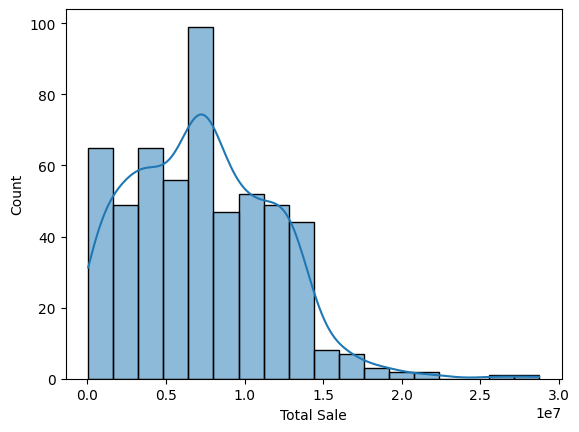

In [ ]:
#The distribution of Total Sales
sns.histplot(x="Total Sale", data=df, kde=True)

<Axes: xlabel='Product', ylabel='Total Sale'>

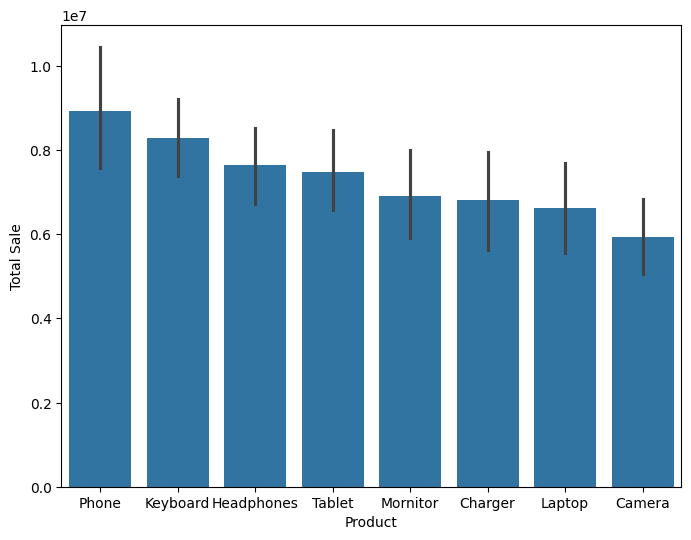

In [27]:
sorted_order = (df.groupby("Product")["Total Sale"].mean().sort_values(ascending=False).index)
plt.figure(figsize=(8,6))
sns.barplot(x = "Product", y = "Total Sale", data=df, order = sorted_order )